# Tutorial 111: Unconditional Flow Matching on Real PBMC Data

In Tutorial 101 we trained on synthetic two-moons data. Here we move to real single-cell data.
The model learns a velocity field that maps standard Gaussian noise to the PBMC cell distribution
in PCA space — effectively learning to **generate realistic synthetic cells**.

* __Source__: Gaussian noise
* __Target__: PBMC single-cell data (50 PCA components, 10,000 cells)

In [1]:
%load_ext autoreload
%autoreload 2

## Contents

* **Section 1**: Data Loading & Preprocessing
* **Section 2**: SCFlow Register Setup
* **Section 3**: Model Setup
* **Section 4**: Training
* **Section 5**: Saving & Loading Model
* **Section 6**: Testing
* **Section 7**: ODE Trajectories

In [2]:
import anndata as ad
import numpy as np
import scanpy as sc
import torch
import matplotlib.pyplot as plt

from sc_flow import SCFlow
from sc_flow.preprocessing import PCATransform, ZScoreTransform

SEED = 40
np.random.seed(SEED)
torch.manual_seed(SEED)

## Section 1: Data Loading & Preprocessing

The PBMC dataset contains 10,000 cells profiled across 2,000 highly variable genes.
Working directly in gene space is expensive and noisy, so we reduce dimensionality using PCA
before handing the data to the model.

We apply two transforms in sequence:
1. **`PCATransform`** — reduces 2,000 genes to 50 principal components
2. **`ZScoreTransform`** — standardises each PC to zero mean and unit variance

The resulting 50-dim representation is what the flow matching model will operate on

In [3]:
DATA_PATH = r"C:\Users\HP\Documents\munich_work\CellFlow\pbmc_small.h5ad"
adata = sc.read_h5ad(DATA_PATH)
print(adata)

AnnData object with n_obs × n_vars = 10000 × 2000
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine', 'treatment', 'cell_type', 'cytokine_family'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'donor_embeddings', 'esm2_embeddings', 'hvg', 'log1p'


Checking the data, we can see that cells are of different imune cell types and originate from diferent patients. Furthermore, it as been treated with different cytokines to see what changes in these cells.

In [4]:
adata.obs.head(10)

,sample,species,gene_count,tscp_count,mread_count,bc1_wind,bc2_wind,bc3_wind,bc1_well,bc2_well,...,log1p_n_genes_by_counts,log1p_total_counts,total_counts_MT,pct_counts_MT,log1p_total_counts_MT,donor,cytokine,treatment,cell_type,cytokine_family
89_103_005__s1,Donor10_4-1BBL,hg38,2236,4700,8656,89,103,5,H5,p2.A7,...,7.712891,8.455530,56.0,1.191490,4.043051,Donor10,4-1BBL,cytokine,CD8 Naive,TNF
89_103_083__s1,Donor10_4-1BBL,hg38,2222,4337,8235,89,103,83,H5,p2.A7,...,7.706613,8.375169,71.0,1.637076,4.276666,Donor10,4-1BBL,cytokine,B Naive,TNF
89_103_085__s1,Donor10_4-1BBL,hg38,1690,3079,5870,89,103,85,H5,p2.A7,...,7.433075,8.032685,197.0,6.398181,5.288267,Donor10,4-1BBL,cytokine,B Intermediate/Memory,TNF
89_104_009__s1,Donor10_4-1BBL,hg38,1746,3015,5663,89,104,9,H5,p2.A8,...,7.465655,8.011686,84.0,2.786070,4.442651,Donor10,4-1BBL,cytokine,CD14 Mono,TNF
89_104_025__s1,Donor10_4-1BBL,hg38,3182,6986,13153,89,104,25,H5,p2.A8,...,8.065579,8.851807,165.0,2.361867,5.111988,Donor10,4-1BBL,cytokine,CD14 Mono,TNF
89_104_063__s1,Donor10_4-1BBL,hg38,1677,2809,5466,89,104,63,H5,p2.A8,...,7.425358,7.940940,54.0,1.922392,4.007333,Donor10,4-1BBL,cytokine,CD4 Naive,TNF
89_115_172__s1,Donor10_4-1BBL,hg38,1407,2178,4103,89,115,172,H5,p2.B7,...,7.249926,7.686621,34.0,1.561065,3.555348,Donor10,4-1BBL,cytokine,CD8 Naive,TNF
89_115_183__s1,Donor10_4-1BBL,hg38,1259,1928,3624,89,115,183,H5,p2.B7,...,7.138867,7.564757,18.0,0.933610,2.944439,Donor10,4-1BBL,cytokine,NK,TNF
89_116_047__s1,Donor10_4-1BBL,hg38,2619,6170,11773,89,116,47,H5,p2.B8,...,7.870930,8.727616,228.0,3.695300,5.433722,Donor10,4-1BBL,cytokine,CD4 Memory,TNF
89_116_148__s1,Donor10_4-1BBL,hg38,1649,3169,6010,89,116,148,H5,p2.B8,...,7.408531,8.061487,38.0,1.199116,3.663562,Donor10,4-1BBL,cytokine,NK,TNF


In [5]:
N_COMPONENTS = 50

X_raw = adata.X.toarray()

pca = PCATransform(n_components=N_COMPONENTS)
zscore = ZScoreTransform()


X_pca = pca.fit_transform(X_raw).astype(np.float32)
X_zscore = zscore.fit_transform(X_pca).astype(np.float32)

adata.obsm["X_pca"] = X_pca
adata.obsm["X_zscore"] = X_zscore

print(f"PCA shape: {adata.obsm['X_pca'].shape}")
print(f"PC1 range: [{adata.obsm['X_pca'][:, 0].min():.2f}, {adata.obsm['X_pca'][:, 0].max():.2f}]")

PCA shape: (10000, 50)
PC1 range: [-33.57, 732.16]


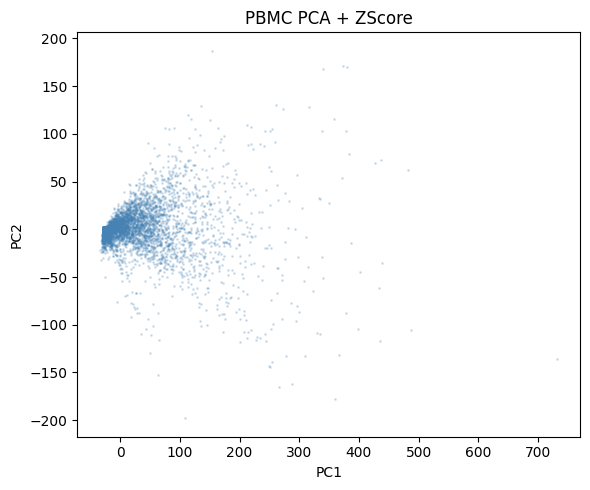

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(adata.obsm["X_pca"][:, 0], adata.obsm["X_pca"][:, 1], s=1, alpha=0.2, color="steelblue")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PBMC PCA + ZScore")
plt.tight_layout()
plt.show()

## Section 2: SCFlow Register Setup

We register the PCA-processed AnnData so SCFlow knows the dimensionality of the state space
(50 PCA components). Since this is an unconditional tutorial there are no conditions,
condition representations, or control populations — just a 50-dim state.

In [7]:
SCFlow.register_adata(
    adata,
    sample_rep="X_pca",
)

In [8]:
print("state_dim:                   ", SCFlow._dims_registry.state_dim)
print("feature_names:               ", SCFlow._dims_registry.feature_names)
print("condition_reps_dims:         ", SCFlow._dims_registry.condition_reps_dims)
print("condition_continuous_dims:   ", SCFlow._dims_registry.condition_continuous_dims)
print("source_lin_dim:              ", SCFlow._dims_registry.source_lin_dim)
print("source_quad_dim:             ", SCFlow._dims_registry.source_quad_dim)
print("target_lin_dim:              ", SCFlow._dims_registry.target_lin_dim)
print("target_quad_dim:             ", SCFlow._dims_registry.target_quad_dim)

state_dim:                    50
feature_names:                Index(['X_pca_0', 'X_pca_1', 'X_pca_2', 'X_pca_3', 'X_pca_4', 'X_pca_5',
       'X_pca_6', 'X_pca_7', 'X_pca_8', 'X_pca_9', 'X_pca_10', 'X_pca_11',
       'X_pca_12', 'X_pca_13', 'X_pca_14', 'X_pca_15', 'X_pca_16', 'X_pca_17',
       'X_pca_18', 'X_pca_19', 'X_pca_20', 'X_pca_21', 'X_pca_22', 'X_pca_23',
       'X_pca_24', 'X_pca_25', 'X_pca_26', 'X_pca_27', 'X_pca_28', 'X_pca_29',
       'X_pca_30', 'X_pca_31', 'X_pca_32', 'X_pca_33', 'X_pca_34', 'X_pca_35',
       'X_pca_36', 'X_pca_37', 'X_pca_38', 'X_pca_39', 'X_pca_40', 'X_pca_41',
       'X_pca_42', 'X_pca_43', 'X_pca_44', 'X_pca_45', 'X_pca_46', 'X_pca_47',
       'X_pca_48', 'X_pca_49'],
      dtype='object')
condition_reps_dims:          {}
condition_continuous_dims:    {}
source_lin_dim:               50
source_quad_dim:              None
target_lin_dim:               50
target_quad_dim:              None


## Section 3: Model Setup

Now we create an SCFlow model instance. There are no changes here. it is the same as the last notebook.

In [9]:
model = SCFlow(
    method_id="cfm",
    backend="torch",
    generate_from_noise=True,
    vf_decoder_mlp_kwargs={
        "hidden_dims": [
            32,
            32,
        ]
    },
)

In [10]:
print(f"Backend:         {model.backend}")
print(f"DataManager:     {model.dm}")
print(f"Method:          {model.method}")
print(f"Paired Settings: {model.is_paired_setting}")

Backend:         torch
DataManager:     <sc_flow.data._manager.DataManager object at 0x000001D8DE161BE0>
Method:          <sc_flow.backends.torch.methods.library._cfm.CFM object at 0x000001D8E87D8EC0>
Paired Settings: False


## Section 4: Training

Once again, training is the same as the previous notebook

In [11]:
BATCH_SIZE = 256
model.train(
    adata,
    n_train_steps=10_000,
    train_batch_size=BATCH_SIZE,
    optim_kwargs={"lr": 1e-4},
)

c:\Users\HP\Documents\munich_work\sc-flow-tools\sc_flow_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 1/1 [00:00<00:00, 3454.95it/s]
| loss:43.9458 | step:10000: 100%|██████████| 10000/10000 [00:49<00:00, 203.05it/s]


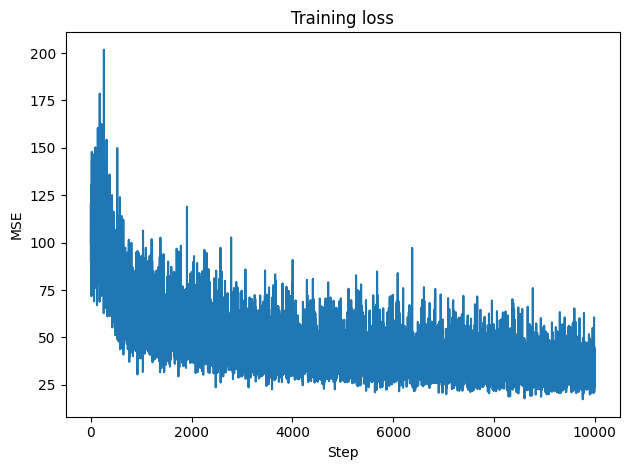

In [12]:
logs_df = model.trainer.get_train_logs_df()
plt.plot(logs_df.index, logs_df["loss"])
plt.title("Training loss")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.tight_layout()
plt.show()

## Section 5: Saving & Loading Model

By default, SCFlow does not allow you to overwrite a saved model. However, if you wish to still overwrite it, we can use `allow_overwrite`

In [13]:
model.save(filepath="cfm_pbmc_model.pt", allow_overwrite=True)

In [14]:
model = SCFlow.load(filepath="cfm_pbmc_model.pt")

## Section 6: Testing

We sample fresh Gaussian noise, wrap it in an AnnData, and pass it to `model.predict`.
The output cells should occupy the same region of PCA space as the real PBMC cells —
confirming the model learned the target distribution. When we registered the adata, we mentioned that the sample representation is `X_pca`, the model will only look for this even when predicting, so we need to make sure that out test data has `.obsm['X_pca]`

In [15]:
N_GENERATE = 1000
noise_input = np.random.randn(N_GENERATE, N_COMPONENTS).astype(np.float32)
adata_source = ad.AnnData(X=noise_input)
adata_source.obsm["X_pca"] = noise_input

adata_pred = model.predict(adata_source)
gen_np = np.array(adata_pred.X)
print(adata_pred)

Predicting: 100%|██████████| 1/1 [00:00<00:00,  4.53it/s]

AnnData object with n_obs × n_vars = 1000 × 50


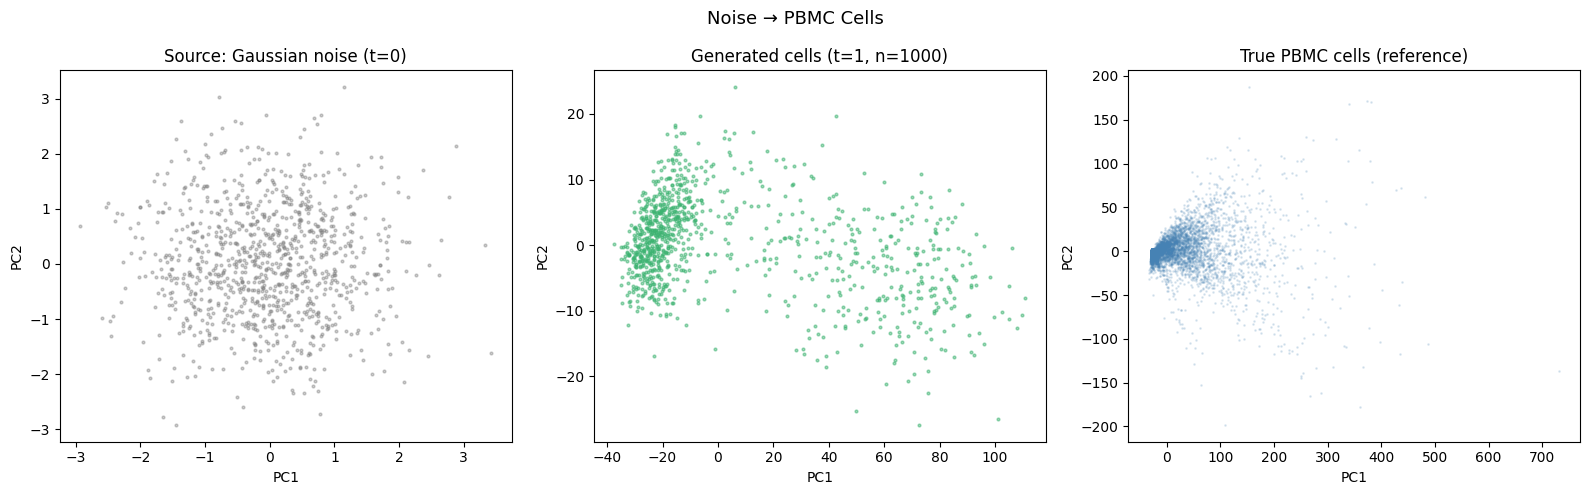

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(noise_input[:, 0], noise_input[:, 1], s=4, alpha=0.4, color="gray")
axes[0].set_title("Source: Gaussian noise (t=0)")

axes[1].scatter(gen_np[:, 0], gen_np[:, 1], s=4, alpha=0.5, color="mediumseagreen")
axes[1].set_title(f"Generated cells (t=1, n={N_GENERATE})")

axes[2].scatter(X_pca[:, 0], X_pca[:, 1], s=1, alpha=0.15, color="steelblue")
axes[2].set_title("True PBMC cells (reference)")

for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.suptitle("Noise → PBMC Cells", fontsize=13)
plt.tight_layout()
plt.show()

## Section 7: ODE Trajectories

We visualise how 30 noise inputs travel through PCA space as the ODE integrates from t=0 to t=1.
Since the model operates in 50-dim PCA space we project each trajectory down to PC1 vs PC2.

> **Note**: Plotting 50-dim trajectories in 2D is only an approximation of the true movement.

In [17]:
N_TRAJ = 30
noise_small = np.random.randn(N_TRAJ, N_COMPONENTS).astype(np.float32)
adata_traj_source = ad.AnnData(X=noise_small)
adata_traj_source.obsm["X_pca"] = noise_small

adata_traj = model.predict(adata_traj_source, return_trajectory=True, num_steps=20)
traj = adata_traj.obsm["trajectory"]  # shape: (n_cells, n_steps, state_dim)
print(f"trajectory shape: {traj.shape}")

Predicting: 100%|██████████| 1/1 [00:00<00:00, 95.55it/s]

trajectory shape: (30, 20, 50)


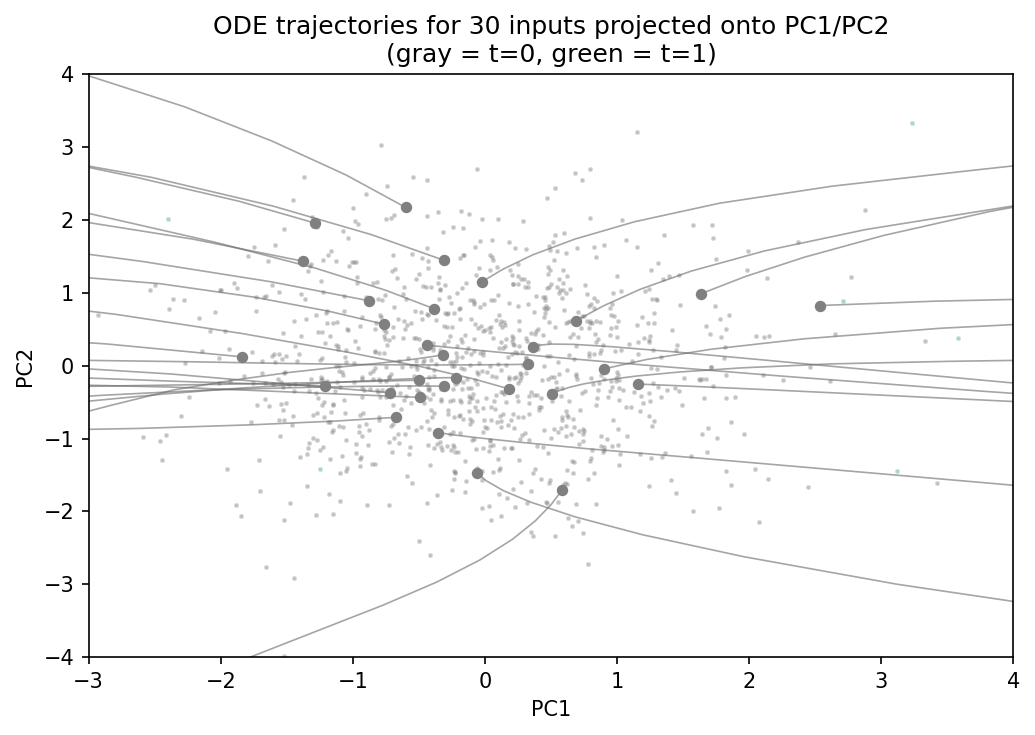

In [18]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=150)

ax.scatter(noise_input[:, 0], noise_input[:, 1], s=2, alpha=0.3, color="gray")
ax.scatter(gen_np[:, 0], gen_np[:, 1], s=2, alpha=0.3, color="mediumseagreen")

mid = traj.shape[1] // 2
for i in range(N_TRAJ):
    ax.plot(traj[i, :, 0], traj[i, :, 1], lw=0.8, alpha=0.6, color="dimgray")
    ax.annotate(
        "",
        xy=(traj[i, mid + 1, 0], traj[i, mid + 1, 1]),
        xytext=(traj[i, mid, 0], traj[i, mid, 1]),
        arrowprops={"arrowstyle": "->", "color": "dimgray", "lw": 1.2},
    )
    ax.scatter(traj[i, 0, 0], traj[i, 0, 1], s=20, color="gray", zorder=5)
    ax.scatter(traj[i, -1, 0], traj[i, -1, 1], s=20, color="mediumseagreen", zorder=5)

ax.set_xlim(-3, 4)
ax.set_ylim(-4, 4)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"ODE trajectories for {N_TRAJ} inputs projected onto PC1/PC2\n(gray = t=0, green = t=1)")
plt.tight_layout()
plt.show()

### What's next?

| Tutorial | What it introduces |
|---|---|
| [`201_conditional_fm_synthetic.ipynb`](201_conditional_fm_synthetic.ipynb) | Conditional FM on synthetic data — one model, two transport maps |
| [`211_conditional_fm_pbmc.ipynb`](211_conditional_fm_pbmc.ipynb) | Conditional FM on real PBMC data with 90 cytokine conditions and ESM2 embeddings |